In [23]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import fsps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fsps.filters import FILTERS

In [24]:
dat_dir = "../data/"
mw_path = os.path.join(dat_dir, "mw_gcs/mw_gcs.csv")
mw_gcs = pd.read_csv(mw_path)

In [25]:
band_type = "JC"
bands = ["v"]

In [26]:
assert (band_type == "JC") | (band_type == "SDSS"), "band_type must be JC or SDSS"

if band_type == "JC":
    compute_vega_mags = True
elif band_type == "SDSS":
    compute_vega_mags = False

sp = fsps.StellarPopulation(imf_type=2, zcontinuous=1, compute_vega_mags=compute_vega_mags)
sp.params["add_dust_emission"] = False
sp.params["dust1"] = 0
sp.params["dust2"] = 0
sp.params["fcstar"] = 0.0
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0

In [27]:
mw_gcs.keys()

Index(['cluster_name', 'ra', 'dec', 'l', 'b', 'r_sun', 'r_sun_err', 'r_gc',
       'rv', 'rv_err', 'pm_ra', 'pm_ra_err', 'pm_dec', 'pm_dec_err',
       'ra_dec_cor', 'x_gc', 'x_gc_err', 'y_gc', 'y_gc_err', 'z_gc',
       'z_gc_err', 'u', 'u_err', 'v', 'v_err', 'w', 'w_err', 'r_per',
       'r_per_err', 'r_apo', 'r_apo_err', 'r_cyl', 'phi_cyl', 'z_cyl',
       'vr_cyl', 'vphi_cyl', 'vz_cyl', 'r_sph', 'theta_sph', 'phi_sph',
       'vr_sph', 'vtheta_sph', 'vphi_sph', 'jr', 'jphi', 'jz', 'jtot', 'lx',
       'ly', 'lz', 'ltot', 'ep', 'ek', 'et', 'inclination', 'circularity',
       'z_max', 'eccentricity', 'V', 'r_hl_pc', 'mass', 'age_gyr', 'feh',
       'EBV', 'V_abs', 'mass_class', 'class', 'age_assume'],
      dtype='object')

In [51]:
ages = np.array(mw_gcs["age_gyr"])
fehs = np.array(mw_gcs["feh"])
mass = np.array(mw_gcs["mass"])
vabs = np.array(mw_gcs["V_abs"])

msk = ~np.isnan(ages) & ~np.isnan(fehs)

ages = ages[msk]
fehs = fehs[msk]
mass = mass[msk]
vabs = vabs[msk]

In [59]:
mags = []

for age, feh, mas in zip(ages, fehs, mass):
    sp.params["logzsol"] = feh
    ssp_mag = sp.get_mags(tage=age, bands=bands)[0]
    ssp_mass = sp.stellar_mass

    scaling = mas / ssp_mass
    mag = ssp_mag - 2.5 * np.log10(scaling)
    mags.append(mag)
mags = np.array(mags)

Text(0, 0.5, 'M_V FSPS')

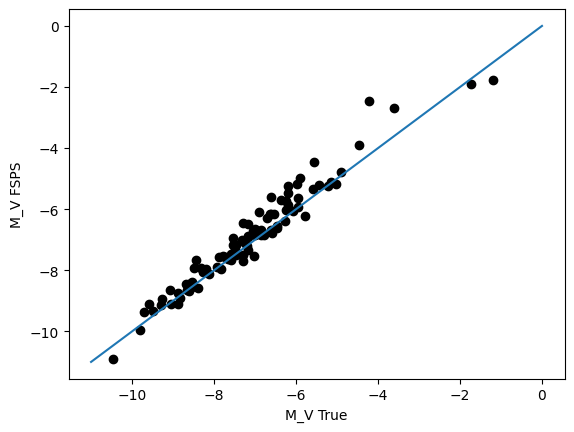

In [65]:
plt.scatter(vabs, mags, c="k")
plt.plot([-11, 0], [-11, 0])

plt.xlabel("M_V True")
plt.ylabel("M_V FSPS")